# Mean-Variance Portfolio Optimization on a Multi-Asset ETF Universe

**Abhiram Vadlamani**

This project implements the Markowitz mean-variance framework end-to-end on a
seven-asset ETF universe and benchmarks the resulting Sharpe-optimal allocation
against a commercial robo-advisor's published model portfolio.

The pipeline estimates return moments from five years of daily data, solves for
the minimum-variance and tangency (maximum-Sharpe) portfolios under a
no-shorting constraint via sequential least-squares quadratic programming
(SLSQP), traces the efficient frontier, and derives the optimal split between
the risky portfolio and the risk-free asset for an investor with quadratic
utility.

**Headline result.** Over the 2016&ndash;2021 sample, the constrained tangency
portfolio achieves an annualised Sharpe ratio of **0.87** (7.88% return, 9.03%
volatility), versus **0.68** for a representative commercial robo-advisor
allocation (5.74% return, 8.46% volatility) on the same asset universe and
estimation window &mdash; a ~28% improvement in risk-adjusted return that comes
entirely from re-weighting the same building blocks.


## 1. Methodology

Let $\mu \in \mathbb{R}^N$ be the vector of expected (annualised) asset returns
and $\Sigma \in \mathbb{R}^{N\times N}$ the return covariance matrix. For a
weight vector $w$ with $w^\top \mathbf{1} = 1$, annualised portfolio return and
variance are

$$
\mu_p = w^\top \mu, \qquad \sigma_p^2 = w^\top \Sigma\, w .
$$

**Tangency (maximum-Sharpe) portfolio.** Given a risk-free rate $r_f$, the
tangency portfolio maximises the Sharpe ratio

$$
S(w) = \frac{w^\top \mu - r_f}{\sqrt{w^\top \Sigma\, w}}
\quad \text{s.t.} \quad w^\top \mathbf{1} = 1,\; 0.05 \le w_i \le 1 .
$$

The lower bound $w_i \ge 5\%$ enforces a diversification floor and keeps the
optimiser away from corner solutions driven by estimation noise in $\mu$.

**Efficient frontier.** Sweeping a target return $\mu^\*$ and solving
$\min_w w^\top \Sigma w$ subject to $w^\top \mu = \mu^\*$ traces the frontier of
minimum-variance portfolios.

**Capital allocation.** Under mean-variance utility
$U = E(r) - 4\alpha\sigma^2$, an investor splitting wealth between the tangency
portfolio $p$ and the risk-free asset (fraction $y$ in the risky portfolio)
maximises

$$
U = \big(y\,E(r_p) + (1-y)\,r_f\big) - 4\alpha y^2 \sigma_p^2 ,
$$

which yields the closed-form optimum (derived in Section 5)

$$
y^\* = \frac{E(r_p) - r_f}{8\alpha\,\sigma_p^2}.
$$


## 2. Setup

In [ ]:
import scipy.optimize as sco
import scipy.stats as scs
import numpy as np
import pandas as pd

import yfinance as yf
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## 3. Asset universe and data

The universe spans seven Australian-listed ETFs covering domestic and
international equities (hedged and unhedged), global listed property,
infrastructure, fixed income, and a cash proxy used as the risk-free asset:

| Ticker | Exposure |
|---|---|
| `STW.AX` | Australian equities (ASX 200) |
| `VGS.AX` | International equities (unhedged) |
| `VGAD.AX` | International equities (AUD-hedged) |
| `DJRE.AX` | Global listed property |
| `IFRA.AX` | Global infrastructure |
| `IAF.AX` | Australian fixed income |
| `AAA.AX` | Cash (risk-free proxy) |

Daily adjusted-close prices are pulled from Yahoo Finance for 1 Jul 2016
&ndash; 30 Jun 2021 and converted to simple daily returns.


In [1]:
ticker_list = ['STW.AX', 'VGS.AX', 'VGAD.AX', 'DJRE.AX', 'IFRA.AX', 'AAA.AX', 'IAF.AX']

# download daily price data for each ETF
df_list = []
for ticker in ticker_list:
    data = yf.download(ticker, start="2016-07-01", end="2021-06-30",
                       group_by="Ticker", period='1d')
    data['ticker'] = ticker
    df_list.append(data)

# combine, keep adjusted close, and pivot to a wide ticker-by-date table
df = pd.concat(df_list)
df = df.filter(['Adj Close', 'ticker'])
df = df.pivot(columns='ticker')
df.columns = [col[1] for col in df.columns]

# convert prices to daily simple returns
df = df.pct_change()
df = df.iloc[1:, :]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## 4. Estimating return moments

`AAA.AX` (cash) is set aside as the risk-free asset; its annualised mean return
defines $r_f$. For the remaining six risky assets we estimate the mean return
vector $\mu$ and the covariance matrix $\Sigma$, annualising by the 252
trading-day convention. The daily return series are plotted to sanity-check the
data and visualise the relative volatility of each sleeve.


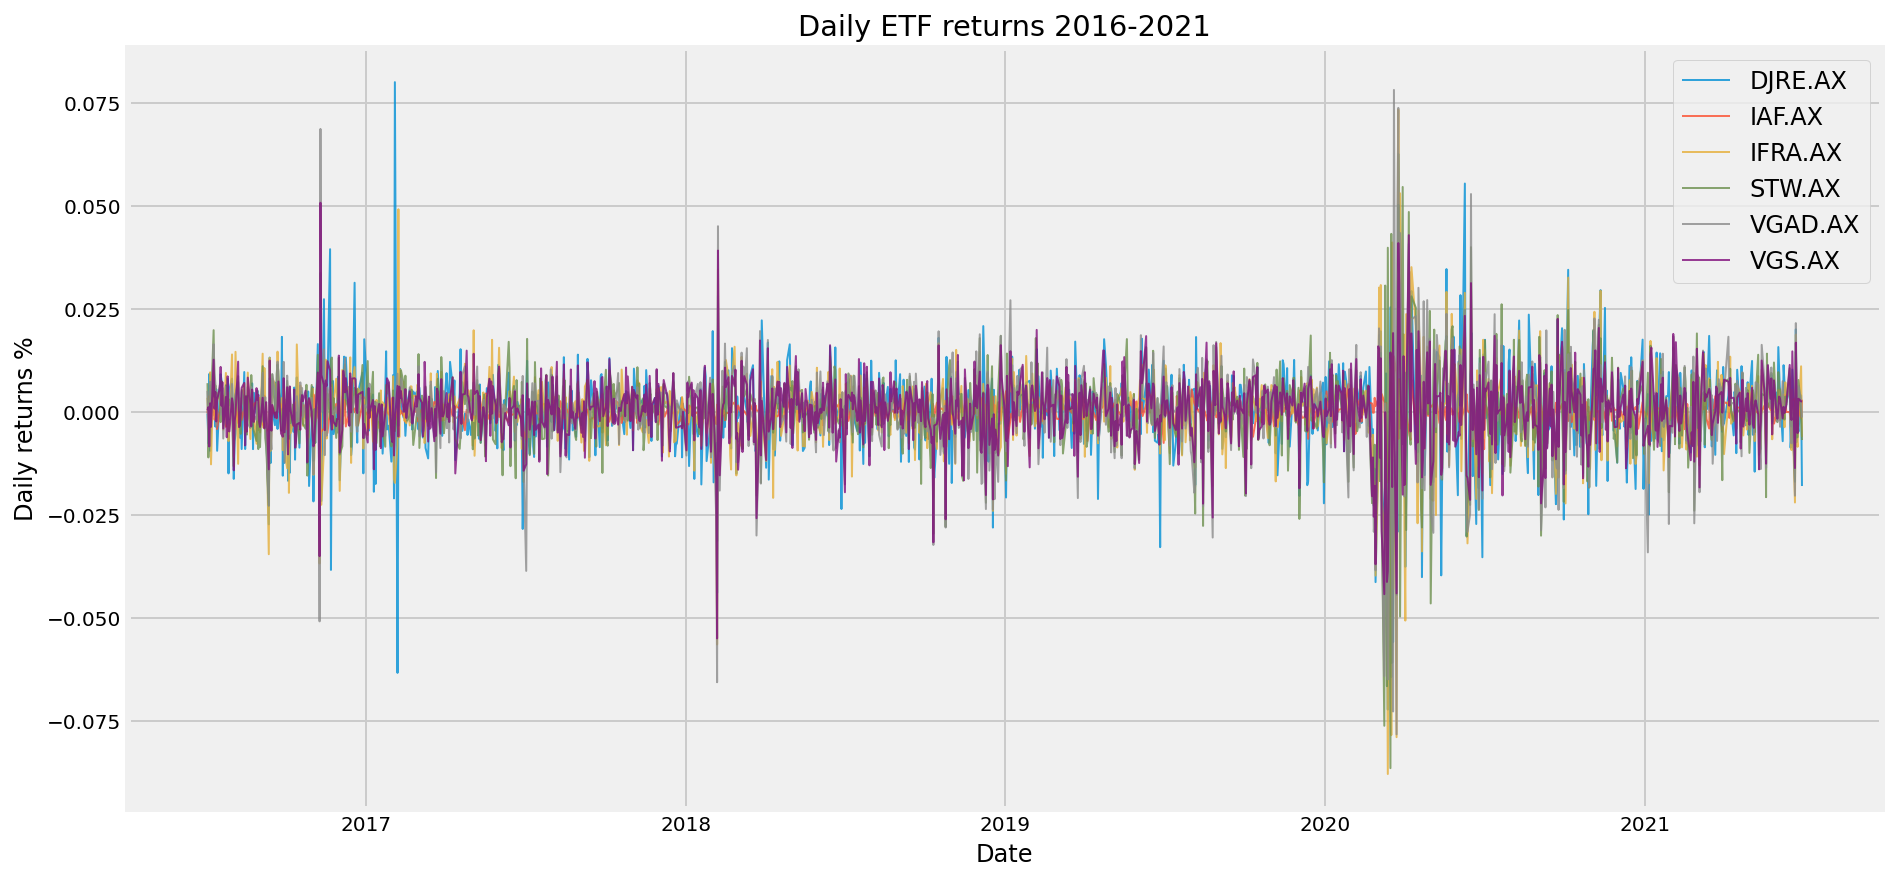

In [2]:
# risk-free rate from the cash ETF, then drop it from the risky universe
risk_free_rate = df["AAA.AX"].mean() * 252
df = df.drop(['AAA.AX'], axis=1)

# annualisable moments of the risky assets
mean_returns = df.mean()
cov_matrix = df.cov()

# daily return time series
plt.figure(figsize=(14, 7))
for c in df.columns.values:
    plt.plot(df.index, df[c], lw=1, alpha=0.8, label=c)
plt.legend(loc='upper right', fontsize=12)
plt.ylabel('Daily returns %')
plt.xlabel('Date')
plt.title('Daily ETF returns 2016-2021')
plt.show()

## 5. Efficient frontier and the tangency portfolio

The block below defines the optimisation toolkit:

- `portfolio_annualised_performance` &mdash; maps weights to annualised
  $(\sigma_p, \mu_p)$.
- `min_variance` / `max_sharpe_ratio` &mdash; SLSQP solvers for the
  minimum-variance and tangency portfolios under the budget constraint
  $w^\top\mathbf{1}=1$ and the box constraint $0.05 \le w_i \le 1$.
- `efficient_return` / `efficient_frontier` &mdash; solve for the
  minimum-variance portfolio at each target return to trace the frontier.
- `display_calculated_ef` &mdash; reports the tangency allocation and plots the
  frontier with each asset and the maximum-Sharpe point.


In [3]:
# annualised return and standard deviation of a portfolio
def portfolio_annualised_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights) * 252
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
    return std, returns


def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_annualised_performance(weights, mean_returns, cov_matrix)[0]


# objective for the tangency portfolio (minimise the negative Sharpe ratio)
def neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    p_std, p_ret = portfolio_annualised_performance(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_std


# minimum-variance portfolio
def min_variance(mean_returns, cov_matrix):
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = [(0.05, 1.0) for _ in range(num_assets)]
    result = sco.minimize(portfolio_volatility, num_assets * [1. / num_assets],
                          args=args, method='SLSQP', bounds=bounds,
                          constraints=constraints)
    return result


# maximum-Sharpe (tangency) portfolio
def max_sharpe_ratio(mean_returns, cov_matrix, risk_free_rate):
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix, risk_free_rate)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = [(0.05, 1.0) for _ in range(num_assets)]
    result = sco.minimize(neg_sharpe_ratio, num_assets * [1. / num_assets],
                          args=args, method='SLSQP', bounds=bounds,
                          constraints=constraints)
    return result


# minimum-variance portfolio achieving a given target return
def efficient_return(mean_returns, cov_matrix, target):
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix)

    def portfolio_return(weights):
        return portfolio_annualised_performance(weights, mean_returns, cov_matrix)[1]

    constraints = ({'type': 'eq', 'fun': lambda x: portfolio_return(x) - target},
                   {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = [(0.05, 1) for _ in range(num_assets)]
    result = sco.minimize(portfolio_volatility, num_assets * [1. / num_assets],
                          args=args, method='SLSQP', bounds=bounds,
                          constraints=constraints)
    return result


def efficient_frontier(mean_returns, cov_matrix, returns_range):
    return [efficient_return(mean_returns, cov_matrix, ret) for ret in returns_range]


# report the tangency allocation and plot the efficient frontier
def display_calculated_ef(mean_returns, cov_matrix, risk_free_rate):
    max_sharpe = max_sharpe_ratio(mean_returns, cov_matrix, risk_free_rate)
    sdp, rp = portfolio_annualised_performance(max_sharpe['x'], mean_returns, cov_matrix)
    max_sharpe_allocation = pd.DataFrame(max_sharpe.x, index=mean_returns.index,
                                         columns=['allocation'])
    max_sharpe_allocation.allocation = [round(i * 100, 3) for i in max_sharpe_allocation.allocation]
    max_sharpe_allocation = max_sharpe_allocation.T

    min_vol = min_variance(mean_returns, cov_matrix)
    sdp_min, rp_min = portfolio_annualised_performance(min_vol['x'], mean_returns, cov_matrix)

    an_vol = pd.Series([np.sqrt(i) * np.sqrt(252) for i in np.diag(cov_matrix)],
                       index=mean_returns.index)
    an_rt = mean_returns * 252

    print("-" * 80)
    print("Maximum Sharpe ratio portfolio allocation\n")
    print("Annualised return:", round(rp, 3))
    print("Annualised volatility:", round(sdp, 3))
    print("\n")
    print(max_sharpe_allocation)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(an_vol, an_rt, marker='o', s=200)
    for i, txt in enumerate(mean_returns.index):
        ax.annotate(txt, (an_vol[i], an_rt[i]), xytext=(10, 0), textcoords='offset points')
    ax.scatter(sdp, rp, marker='*', color='r', s=500, label='Maximum Sharpe ratio')

    target = np.linspace(rp_min, 0.109, 50)
    efficient_portfolios = efficient_frontier(mean_returns, cov_matrix, target)
    plt.plot([p['fun'] for p in efficient_portfolios], target,
             linestyle='-.', color='black', label='efficient frontier')

    ax.set_title('Efficient frontier and tangency portfolio')
    ax.set_xlabel('Annualised std. deviation %')
    ax.set_ylabel('Annualised returns %')
    ax.legend(labelspacing=0.8, loc='upper left')

--------------------------------------------------------------------------------
Maximum Sharpe ratio portfolio allocation

Annualised return: 0.079
Annualised volatility: 0.09


            DJRE.AX  IAF.AX  IFRA.AX  STW.AX  VGAD.AX  VGS.AX
allocation      5.0  29.164      5.0     5.0      5.0  50.836


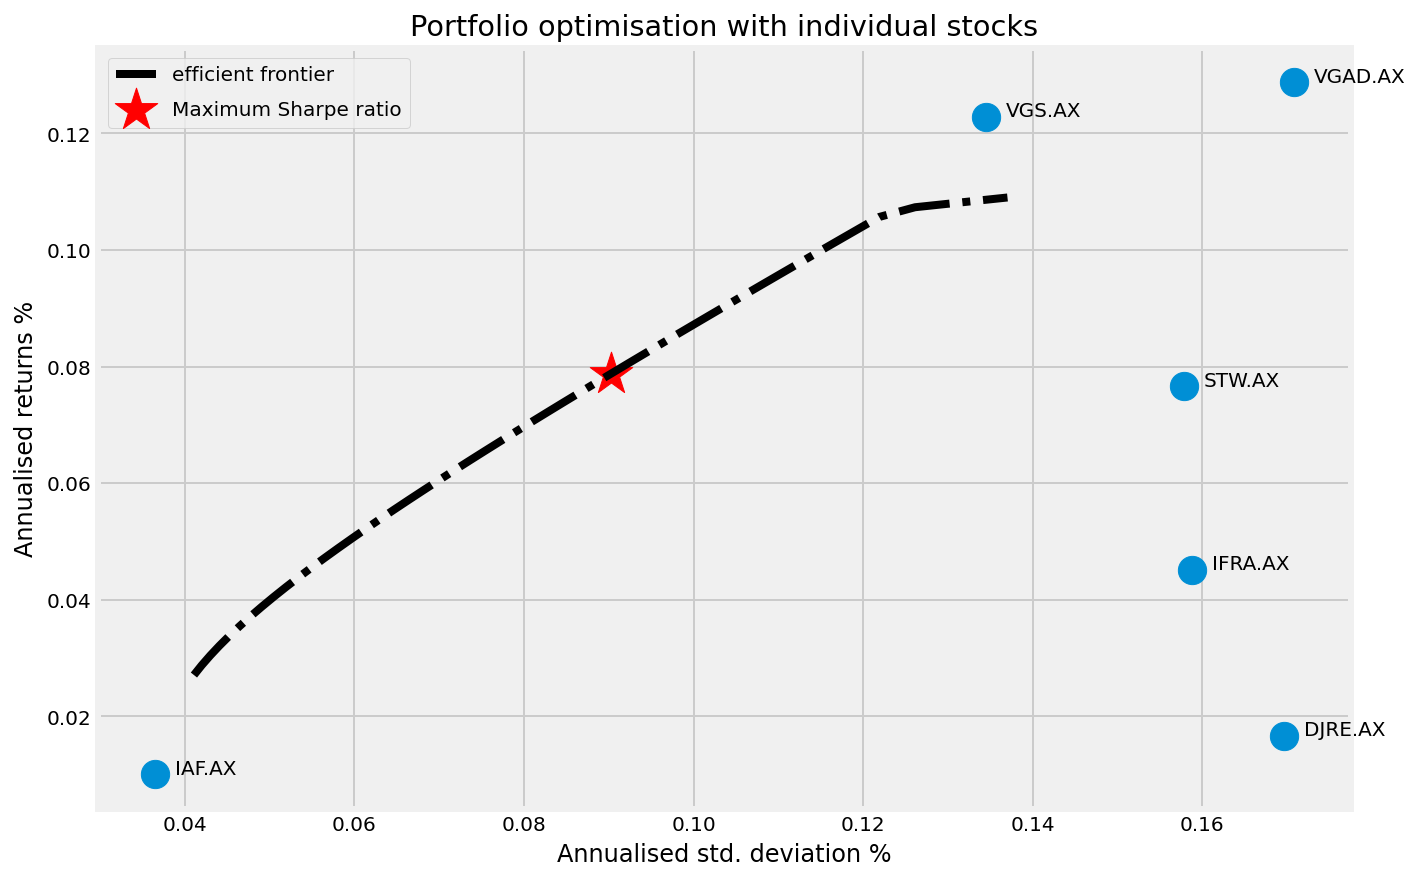

In [4]:
display_calculated_ef(mean_returns, cov_matrix, risk_free_rate)

The tangency portfolio concentrates in unhedged international equities
(`VGS.AX`, ~51%) and Australian fixed income (`IAF.AX`, ~29%), with the
remaining sleeves pinned at the 5% diversification floor. This is the
risk-adjusted-optimal mix of risky assets; every investor holds it regardless
of risk appetite, varying only how much they lever it against cash (Section 5).


## 6. Optimal capital allocation

With the tangency portfolio fixed, the only remaining decision is the fraction
$y$ of wealth held in it versus the risk-free asset. Maximising the
mean-variance utility

$$
U = \big(y E(r_p) + (1-y) r_f\big) - 4\alpha y^2 \sigma_p^2
$$

with respect to $y$:

$$
\frac{\partial U}{\partial y}
= E(r_p) - r_f - 8 y \alpha \sigma_p^2 = 0
\;\;\Longrightarrow\;\;
y^\* = \frac{E(r_p) - r_f}{8\alpha\,\sigma_p^2}.
$$

For an illustrative investor with risk-aversion coefficient $\alpha = 1.7$, the
function below returns the percentage split between the risky tangency portfolio
and the risk-free asset.


In [5]:
def find_complete_portfolio(mean_returns, cov_matrix, risk_free_rate, alpha):
    """Optimal split between the tangency portfolio and the risk-free asset.

    Returns (weight_risky, weight_risk_free) as percentages, where
    weight_risky = y* = (E[r_p] - r_f) / (8 * alpha * sigma_p^2).
    """
    max_sharpe = max_sharpe_ratio(mean_returns, cov_matrix, risk_free_rate)
    sdp, rp = portfolio_annualised_performance(max_sharpe['x'], mean_returns, cov_matrix)

    weight_risky = ((rp - risk_free_rate) / (8 * alpha * sdp ** 2)) * 100
    weight_risk_free = 100 - weight_risky
    return round(weight_risky, 2), round(weight_risk_free, 2)


find_complete_portfolio(mean_returns, cov_matrix, risk_free_rate, 1.7)

(71.04, 28.96)

The investor allocates **71.04%** to the tangency portfolio and **28.96%** to
cash. More risk-averse investors (higher $\alpha$) shift further toward cash;
the composition of the 71% risky sleeve never changes &mdash; a direct
illustration of the **two-fund separation theorem**.


## 7. Performance evaluation

`evaluate_portfolio_performance` returns the annualised return, volatility, and
Sharpe ratio for an arbitrary set of risky-asset weights, so any candidate
allocation can be scored on the same footing.


In [6]:
def evaluate_portfolio_performance(mean_returns, cov_matrix, risk_free_rate, weights):
    """Annualised return (%), volatility (%), and Sharpe ratio of a weighted
    risky-asset portfolio."""
    sdp, rp = portfolio_annualised_performance(weights, mean_returns, cov_matrix)
    annual_return = rp * 100
    annual_risk = sdp * 100
    annual_sharpe = (rp - risk_free_rate) / sdp
    return round(annual_return, 2), round(annual_risk, 2), round(annual_sharpe, 2)

**Tangency portfolio** (this study):

In [7]:
evaluate_portfolio_performance(
    mean_returns, cov_matrix, risk_free_rate,
    max_sharpe_ratio(mean_returns, cov_matrix, risk_free_rate)['x'])

(7.88, 9.03, 0.87)

## 8. Benchmark: commercial robo-advisor allocation

As an external reference point, we score a representative commercial
robo-advisor's published model portfolio over the **same** asset universe and
estimation window. The benchmark weights below map that provider's recommended
balanced allocation onto the six risky sleeves
(`[DJRE, IAF, IFRA, STW, VGAD, VGS]`):


In [8]:
benchmark_weights = np.array([0.10, 0.3333, 0.1333, 0.1667, 0.1333, 0.1333])

evaluate_portfolio_performance(
    mean_returns, cov_matrix, risk_free_rate, benchmark_weights)

(5.74, 8.46, 0.68)

## 9. Findings

| Portfolio | Ann. return | Ann. volatility | Sharpe |
|---|---|---|---|
| **Tangency (this study)** | 7.88% | 9.03% | **0.87** |
| Commercial robo-advisor benchmark | 5.74% | 8.46% | 0.68 |

Two conclusions follow.

**1. The benchmark is not on the efficient frontier.** The commercial allocation
delivers a materially lower Sharpe ratio (0.68 vs 0.87) at comparable volatility.
Because both portfolios are built from the *same* ETFs over the *same* window,
the entire gap is attributable to weighting &mdash; the optimiser extracts ~28%
more risk-adjusted return purely by reallocating.

**2. The benchmark appears to violate two-fund separation.** Portfolio theory
implies all investors should hold the identical tangency portfolio and express
risk preference only through the cash/risky split. A commercial allocation whose
*risky* composition shifts with the client's stated risk tolerance is therefore
inconsistent with the separation property, and the cost of that inconsistency
shows up directly in the Sharpe differential above.

**Caveats.** Results are in-sample: $\mu$ and $\Sigma$ are estimated on the
same 2016&ndash;2021 window used to evaluate performance, so the tangency
portfolio's edge is an upper bound on what is achievable out-of-sample.
Mean-variance optimisation is notoriously sensitive to estimation error in
$\mu$; the 5% weight floor mitigates but does not eliminate this. Natural
extensions are walk-forward (out-of-sample) backtesting, Ledoit&ndash;Wolf
shrinkage of $\Sigma$, and the inclusion of transaction costs and turnover
constraints.
